In [1]:
import sys

if 'workhorse' not in sys.executable.split('/'):
    origin = 'workspace/'
    sys.path.append('/media/')
else:
    origin = 'data/Aldhani/eoagritwin/'
    sys.path.append('/home/potzschf/repos/')

from helperToolz.polygons_to_labels import *
from helperToolz.helpsters import *
import xarray as xr
import rioxarray
from helperToolz.feevos.rocksdbutils_copy import *
from math import ceil as mceil

INFO:albumentations.check_version:A new version of Albumentations is available: 2.0.8 (you have 1.4.13). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.


In [2]:
# load a rocksdb dataset
fine_set = RocksDBDataset('/workspace/fields/output/rocks_db/Fine_tuner.db/train.db', transform=None)

In [ ]:
ai4_set = RocksDBDataset('/workspace/fields/output/rocks_db/AI4_RGB_exclude_True.db/train.db', transform=None)

In [ ]:
ai4_data = []
ai4_labels = []
for i in range(len(ai4_set)):
    ai4_data.append(np.unique(ai4_set[i][0]))
    ai4_labels.append(np.unique(ai4_set[i][1]))

In [3]:
fine_data = []
fine_labels = []
for i in range(len(fine_set)):
    fine_data.append(np.unique(fine_set[i][0], return_counts=True))
    fine_labels.append(np.unique(fine_set[i][1]))

In [9]:
for count, i in enumerate(fine_data):
    if np.isnan(i[0]).any():
        print(count)

270
271
277
279
280
281
988
989
1539
1649
1824
1825
1826
1827
2196
2197
2198
2199
2200
2550
2553
2666
2668
2676
2737
2738
2739
2740
2741
2948
2949
3002
3003
3043
3045
3046
3047
3162
3163
3164
3165
3166
3167
3235
3236
3237
3238
3239
3342
3343
3420
3421
3424
3425
3510
3511
3512
3513
3583
3587
3650
3793
3796
4082
4083
4130
4131
4171
4172
4174
4175
4182
4183
4184
4185
4204
4254
4255
4256
4257
4284
4287
4288
4289
4356
4357
4359
4360
4361
4394
4395
4416
4417
4418
4419
4578
4579
4580
4581
4590
4591
4592
4593
4720
4808
4809
4864
4865
4918
5292
5293
5295
5296
5297
5582
5583
5609
5819
5878
5879
6257
6309
6354
6355
6581
6589
6593
7072
7073
7196
7197
7262
7263
7264
7500
7604
8058
8059
8060
8061
8062
8063
8128
8129
8300
8313
9451
9454
9829
9831
9832
9833
10164
10167


In [6]:
fine_data_uni = np.unique([f for fd in fine_data for f in fd])
fine_labels_uni = np.unique([f for fd in fine_labels for f in fd])

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (21000,) + inhomogeneous part.

In [ ]:
ai4_data_uni = np.unique([f for fd in ai4_data for f in fd])
ai4_labels_uni = np.unique([f for fd in ai4_labels for f in fd])

In [10]:
# check nc files
variables2use=['B2','B3','B4','B8']
nc_files = getFilelist(f'/{origin}fields/Fine_tune/', '.nc', deep=True)

In [11]:
for i in range(len(nc_files)):
    nc_file = xr.open_dataset(nc_files[i])
    image = np.concatenate([nc_file[var].values[None] for var in variables2use],0)
    if len(np.unique(image)) == 1:
        print(i)
        print(nc_files[i])
        print(np.unique(image))

In [ ]:
label_files = getFilelist(f'/{origin}fields/Fine_tune/', '.tif', deep=True)
for i in range(len(label_files)):
    arr = stackReader(label_files[i])
    print(np.unique(arr))

In [12]:
# mock the normalisation when pressing into rocks
normi = AI4BNormal_S2()

for i in range(len(nc_files)):
    nc_file = xr.open_dataset(nc_files[i])
    image = np.concatenate([nc_file[var].values[None] for var in variables2use],0)
    #plotter(image)
    if np.isnan(np.unique(normi(image))).any() == True:
        print(f'{i}: {nc_files[i]}')

45: /workspace/fields/Fine_tune/img/BRB/2022/BRB_2022_rowstart_12544_colstart_9984.nc
46: /workspace/fields/Fine_tune/img/BRB/2022/BRB_2022_rowstart_12800_colstart_17920.nc
164: /workspace/fields/Fine_tune/img/BRB/2022/BRB_2022_rowstart_18432_colstart_26624.nc
256: /workspace/fields/Fine_tune/img/BRB/2022/BRB_2022_rowstart_23552_colstart_24576.nc
274: /workspace/fields/Fine_tune/img/BRB/2022/BRB_2022_rowstart_25088_colstart_16896.nc
304: /workspace/fields/Fine_tune/img/BRB/2022/BRB_2022_rowstart_5376_colstart_14336.nc
366: /workspace/fields/Fine_tune/img/BRB/2022/BRB_2022_rowstart_8960_colstart_10752.nc
410: /workspace/fields/Fine_tune/img/LSA/2024/LSA_2024_rowstart_10496_colstart_15872.nc
425: /workspace/fields/Fine_tune/img/LSA/2024/LSA_2024_rowstart_10752_colstart_8960.nc
426: /workspace/fields/Fine_tune/img/LSA/2024/LSA_2024_rowstart_11008_colstart_17920.nc
444: /workspace/fields/Fine_tune/img/LSA/2024/LSA_2024_rowstart_11520_colstart_23296.nc
446: /workspace/fields/Fine_tune/img/L

In [13]:
i = 45
nc_file = xr.open_dataset(nc_files[i])
image = np.concatenate([nc_file[var].values[None] for var in variables2use],0)
norm_image = normi(image)
image[np.where(np.isnan(norm_image) == True)]

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan], dtype=float32)

In [19]:
nc_files[45]

'/workspace/fields/Fine_tune/img/BRB/2022/BRB_2022_rowstart_12544_colstart_9984.nc'

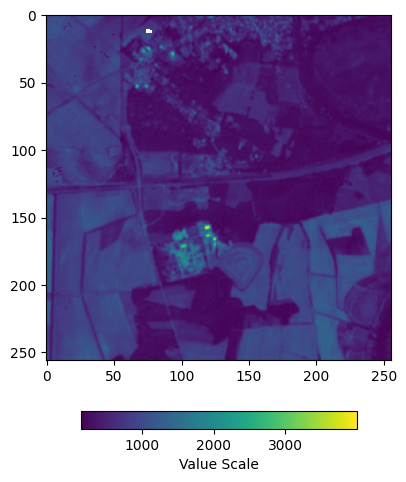

In [25]:
plotter(image[0,5,:,:])#0:30,50:100])